# Entanglement-level statistics: nonequilibrium versus disordered equilibrium
Compare $N_x=20,N_y=32$, hard domain walls, $\alpha_1=1$, $\alpha_2=30$, $n_{\mathrm{shell}}=1$, with 100 pure-state realizations per ensemble. The nonequilibrium states are cycle-64 endpoints. The equilibrium states are half-filled ground states with independent zero-mean Gaussian potentials on every diagonal entry $(x,y,\mu)$, of variance $W^2=0.64,1,4$. Use the same half-system $A_y=16$, fixed origin $y_0=0$, both orbitals, and $|\lambda|\le0.99$.

Within EACH realization, sort $\varepsilon=-2\operatorname{artanh}\lambda$ and compute
$$\delta_n=\varepsilon_{n+1}-\varepsilon_n,\qquad r_n=\frac{\min(\delta_n,\delta_{n+1})}{\max(\delta_n,\delta_{n+1})}.$$
Only afterward pool ratios. No spacing ever joins two different realizations. Histograms and means weight each valid ratio equally. Errors on the pooled mean delete whole realizations in a jackknife. No levels or near-degenerate pairs are merged. Report unresolved double-zero spacings and gaps below $10^{-6}$ separately.

The spacing histogram uses $\delta/\overline\delta$ within each realization; this removes an overall scale but is not full local unfolding. Ratio statistics do not require that scale normalization. The analyzed object is the single-particle entanglement spectrum, with no claim of many-body chaos. The full retained spectrum is analyzed without separating wall branches; reference ensembles are diagnostic comparisons, not assumed classifications.

The clean spectrum is a separate degeneracy control. Repeat ratios at $L=0.5,0.9,0.95$ and omit triples that straddle zero as sensitivity checks. Reference values: Poisson $\langle r\rangle=2\log2-1$; GUE approximately 0.5996 (large-matrix numerical value). The plotted GUE density is the 3-by-3 approximation from [Atas et al.](https://arxiv.org/abs/1212.5611), whose mean is approximately 0.60266. Entanglement-spectrum applications to disordered Chern insulators: [Prodan et al.](https://doi.org/10.1103/PhysRevLett.105.115501).

In [1]:
import os
CPU_RANGE=(8,15)
selected=list(range(CPU_RANGE[0],CPU_RANGE[1]+1))
assert set(selected).issubset(os.sched_getaffinity(0))
os.sched_setaffinity(0,selected)
for key in ('OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','OMP_NUM_THREADS'):os.environ[key]=str(len(selected))
print('Allocated CPUs:',selected)

Allocated CPUs: [8, 9, 10, 11, 12, 13, 14, 15]


## Configuration and inputs
Validate the saved spectra by checksum; no dynamics or ground-state diagonalization is repeated.

In [2]:
from pathlib import Path
import json,hashlib,subprocess
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from IPython.display import display,Image
OUT=Path.cwd();BASE=OUT.parents[2]
SMALL=OUT.parent/'half_system_centered_spectrum_n20_sizes_hard_alpha1_v1'
EQ=BASE/'06_domain_wall_flattened_ground_state_reference/analysis_outputs/disordered_full_diagonal_strong_energy_n20x32_v1'
L=.99
WINDOWS=[.5,.9,.95,.99]
ZERO_TOL=1e-12
PAIR_TOL=1e-6
def sha(p):
    with p.open('rb') as f:return hashlib.file_digest(f,'sha256').hexdigest()
inputs=[]
def verify(p,expected):
    digest=sha(p);assert digest==expected
    inputs.append({'path':str(p),'sha256':digest,'bytes':p.stat().st_size})
f=SMALL/'centered_spectra_Ny032.npz'
overlay=json.loads((SMALL/'overlay_diagnostics.json').read_text())
verify(f,overlay['sizes']['32']['spectra_sha256'])
with np.load(f) as z:
    assert np.array_equal(z['sample_ids'],np.arange(100))
    assert np.array_equal(z['subsystem_indices'],np.arange(640))
    arrays={'Nonequilibrium':z['eigenvalues']}
manifest=json.loads((EQ/'completion_manifest.json').read_text())
f=EQ/'spectra_and_energies.npz';verify(f,manifest['files'][f.name]['sha256'])
with np.load(f) as z:
    for i,v in enumerate(z['variances']):arrays[f'W2={v:g}']=z[f'centered_spectra_{i}']
f=EQ/'clean_reference.npz';verify(f,manifest['files'][f.name]['sha256'])
with np.load(f) as z:clean=z['centered_eigenvalues'][None,:]
for a in arrays.values():assert a.shape==(100,640)
assert clean.shape==(1,640)
labels=list(arrays)
metadata={'Nx':20,'Ny':32,'Ay':16,'origin_y':0,'samples_per_ensemble':100,
 'L':L,'windows':WINDOWS,'zero_spacing_tolerance':ZERO_TOL,'near_pair_spacing_threshold':PAIR_TOL,
 'ratio_weighting':'pool ratios after computing within realizations',
 'error_bars':'one delete-realization jackknife standard error',
 'spacing_scaling':'divide each realization spacings by their mean; not local unfolding',
 'sector_handling':'full retained single-particle spectrum; no branch separation or pair merging'}
(OUT/'input_provenance.json').write_text(json.dumps({'configuration':metadata,'inputs':inputs,
 'equilibrium_provenance':json.loads((EQ/'input_provenance.json').read_text())},indent=2)+'\n')
display(pd.Series(metadata))

Nx                                                                            20
Ny                                                                            32
Ay                                                                            16
origin_y                                                                       0
samples_per_ensemble                                                         100
L                                                                           0.99
windows                                                   [0.5, 0.9, 0.95, 0.99]
zero_spacing_tolerance                                                       0.0
near_pair_spacing_threshold                                             0.000001
ratio_weighting                  pool ratios after computing within realizations
error_bars                       one delete-realization jackknife standard error
spacing_scaling                divide each realization spacings by their mean...
sector_handling             

## Per-realization spacings and ratios
Compute moments and histograms from the original levels. All retained energies must be finite; unresolved ratios are counted explicitly.

In [3]:
def compute(a,window,label):
    ratio_rows=[];spacings=[];ratio_ids=[];sample_rows=[];same_sign=[]
    for sid,lam in enumerate(a):
        assert np.isfinite(lam).all() and np.max(np.abs(lam))<=1+1e-8
        selected=lam[np.abs(lam)<=window]
        e=np.sort(np.log1p(-selected)-np.log1p(selected))
        assert np.isfinite(e).all() and len(e)>=3
        d=np.diff(e)
        assert np.all(d>=0) and d.mean()>0
        den=np.maximum(d[:-1],d[1:])
        valid=den>ZERO_TOL
        r=np.minimum(d[:-1],d[1:])[valid]/den[valid]
        assert np.all((r>=0)&(r<=1))
        same=(e[:-2]*e[2:]>0)[valid]
        same_sign.extend(r[same])
        ratio_rows.extend(r);ratio_ids.extend([sid]*len(r));spacings.extend(d/d.mean())
        sample_rows.append({'ensemble':label,'L':window,'sample_id':sid,'levels':len(e),
           'ratio_count':len(r),'ratio_sum':float(r.sum()),'mean_r':float(r.mean()),
           'spacing_count':len(d),'mean_spacing':float(d.mean()),
           'near_pair_gaps':int((d<PAIR_TOL).sum()),'unresolved_ratios':int((~valid).sum())})
    r=np.array(ratio_rows);ids=np.array(ratio_ids)
    n=np.bincount(ids,minlength=len(a));s=np.bincount(ids,weights=r,minlength=len(a))
    se=None
    if len(a)>1:
        leave=(s.sum()-s)/(n.sum()-n)
        se=float(np.sqrt((len(a)-1)/len(a)*np.sum((leave-leave.mean())**2)))
    row={'ensemble':label,'L':window,'samples':len(a),'total_levels':sum(x['levels'] for x in sample_rows),
         'ratio_count':len(r),'mean_r':float(r.mean()),'mean_r_jackknife_se':se,
         'same_sign_mean_r':float(np.mean(same_sign)),'same_sign_ratio_count':len(same_sign),
         'near_pair_gaps':sum(x['near_pair_gaps'] for x in sample_rows),
         'unresolved_ratios':sum(x['unresolved_ratios'] for x in sample_rows)}
    return r,np.array(spacings),ids,row,sample_rows
results={};summary_rows=[];sample_rows=[];cache={};sensitivity=[]
for i,(label,a) in enumerate(tqdm(arrays.items(),desc='Level statistics',unit='ensemble')):
    for window in WINDOWS:
        r,s,ids,row,sr=compute(a,window,label)
        sensitivity.append(row)
        if window==L:
            results[label]={'ratios':r,'spacings':s,'sample_ids':ids}
            summary_rows.append(row);sample_rows.extend(sr)
            cache[f'ratios_{i}']=r;cache[f'spacings_{i}']=s;cache[f'sample_ids_{i}']=ids
r,s,ids,clean_summary,sr=compute(clean,L,'Clean control')
cache['clean_ratios']=r;cache['clean_spacings']=s
summary=pd.DataFrame(summary_rows)
summary.to_csv(OUT/'level_statistics_summary.csv',index=False)
pd.DataFrame(sample_rows).to_csv(OUT/'sample_level_statistics.csv',index=False)
pd.DataFrame(sensitivity).to_csv(OUT/'window_sensitivity.csv',index=False)
np.savez_compressed(OUT/'level_statistics.npz',**cache,labels=labels,L=L)
display(summary[['ensemble','ratio_count','mean_r','mean_r_jackknife_se','near_pair_gaps']])
print('Clean degeneracy control:',clean_summary)

Level statistics:   0%|          | 0/4 [00:00<?, ?ensemble/s]

,ensemble,ratio_count,mean_r,mean_r_jackknife_se,near_pair_gaps
0,Nonequilibrium,2920,0.902384,0.011521,0
1,W2=0.64,2786,0.979757,0.000395,0
2,W2=1,2760,0.979005,0.000549,0
3,W2=4,2859,0.703068,0.008786,0


Clean degeneracy control: {'ensemble': 'Clean control', 'L': 0.99, 'samples': 1, 'total_levels': 30, 'ratio_count': 28, 'mean_r': 2.4177641922986454e-07, 'mean_r_jackknife_se': None, 'same_sign_mean_r': 2.418218125390185e-07, 'same_sign_ratio_count': 26, 'near_pair_gaps': 15, 'unresolved_ratios': 0}


## Adjacent-gap-ratio distributions
Bar histograms have unit area. The logarithmic vertical axis makes the reference distributions and the nonequilibrium tail visible. Empty bins are omitted on the log axis.

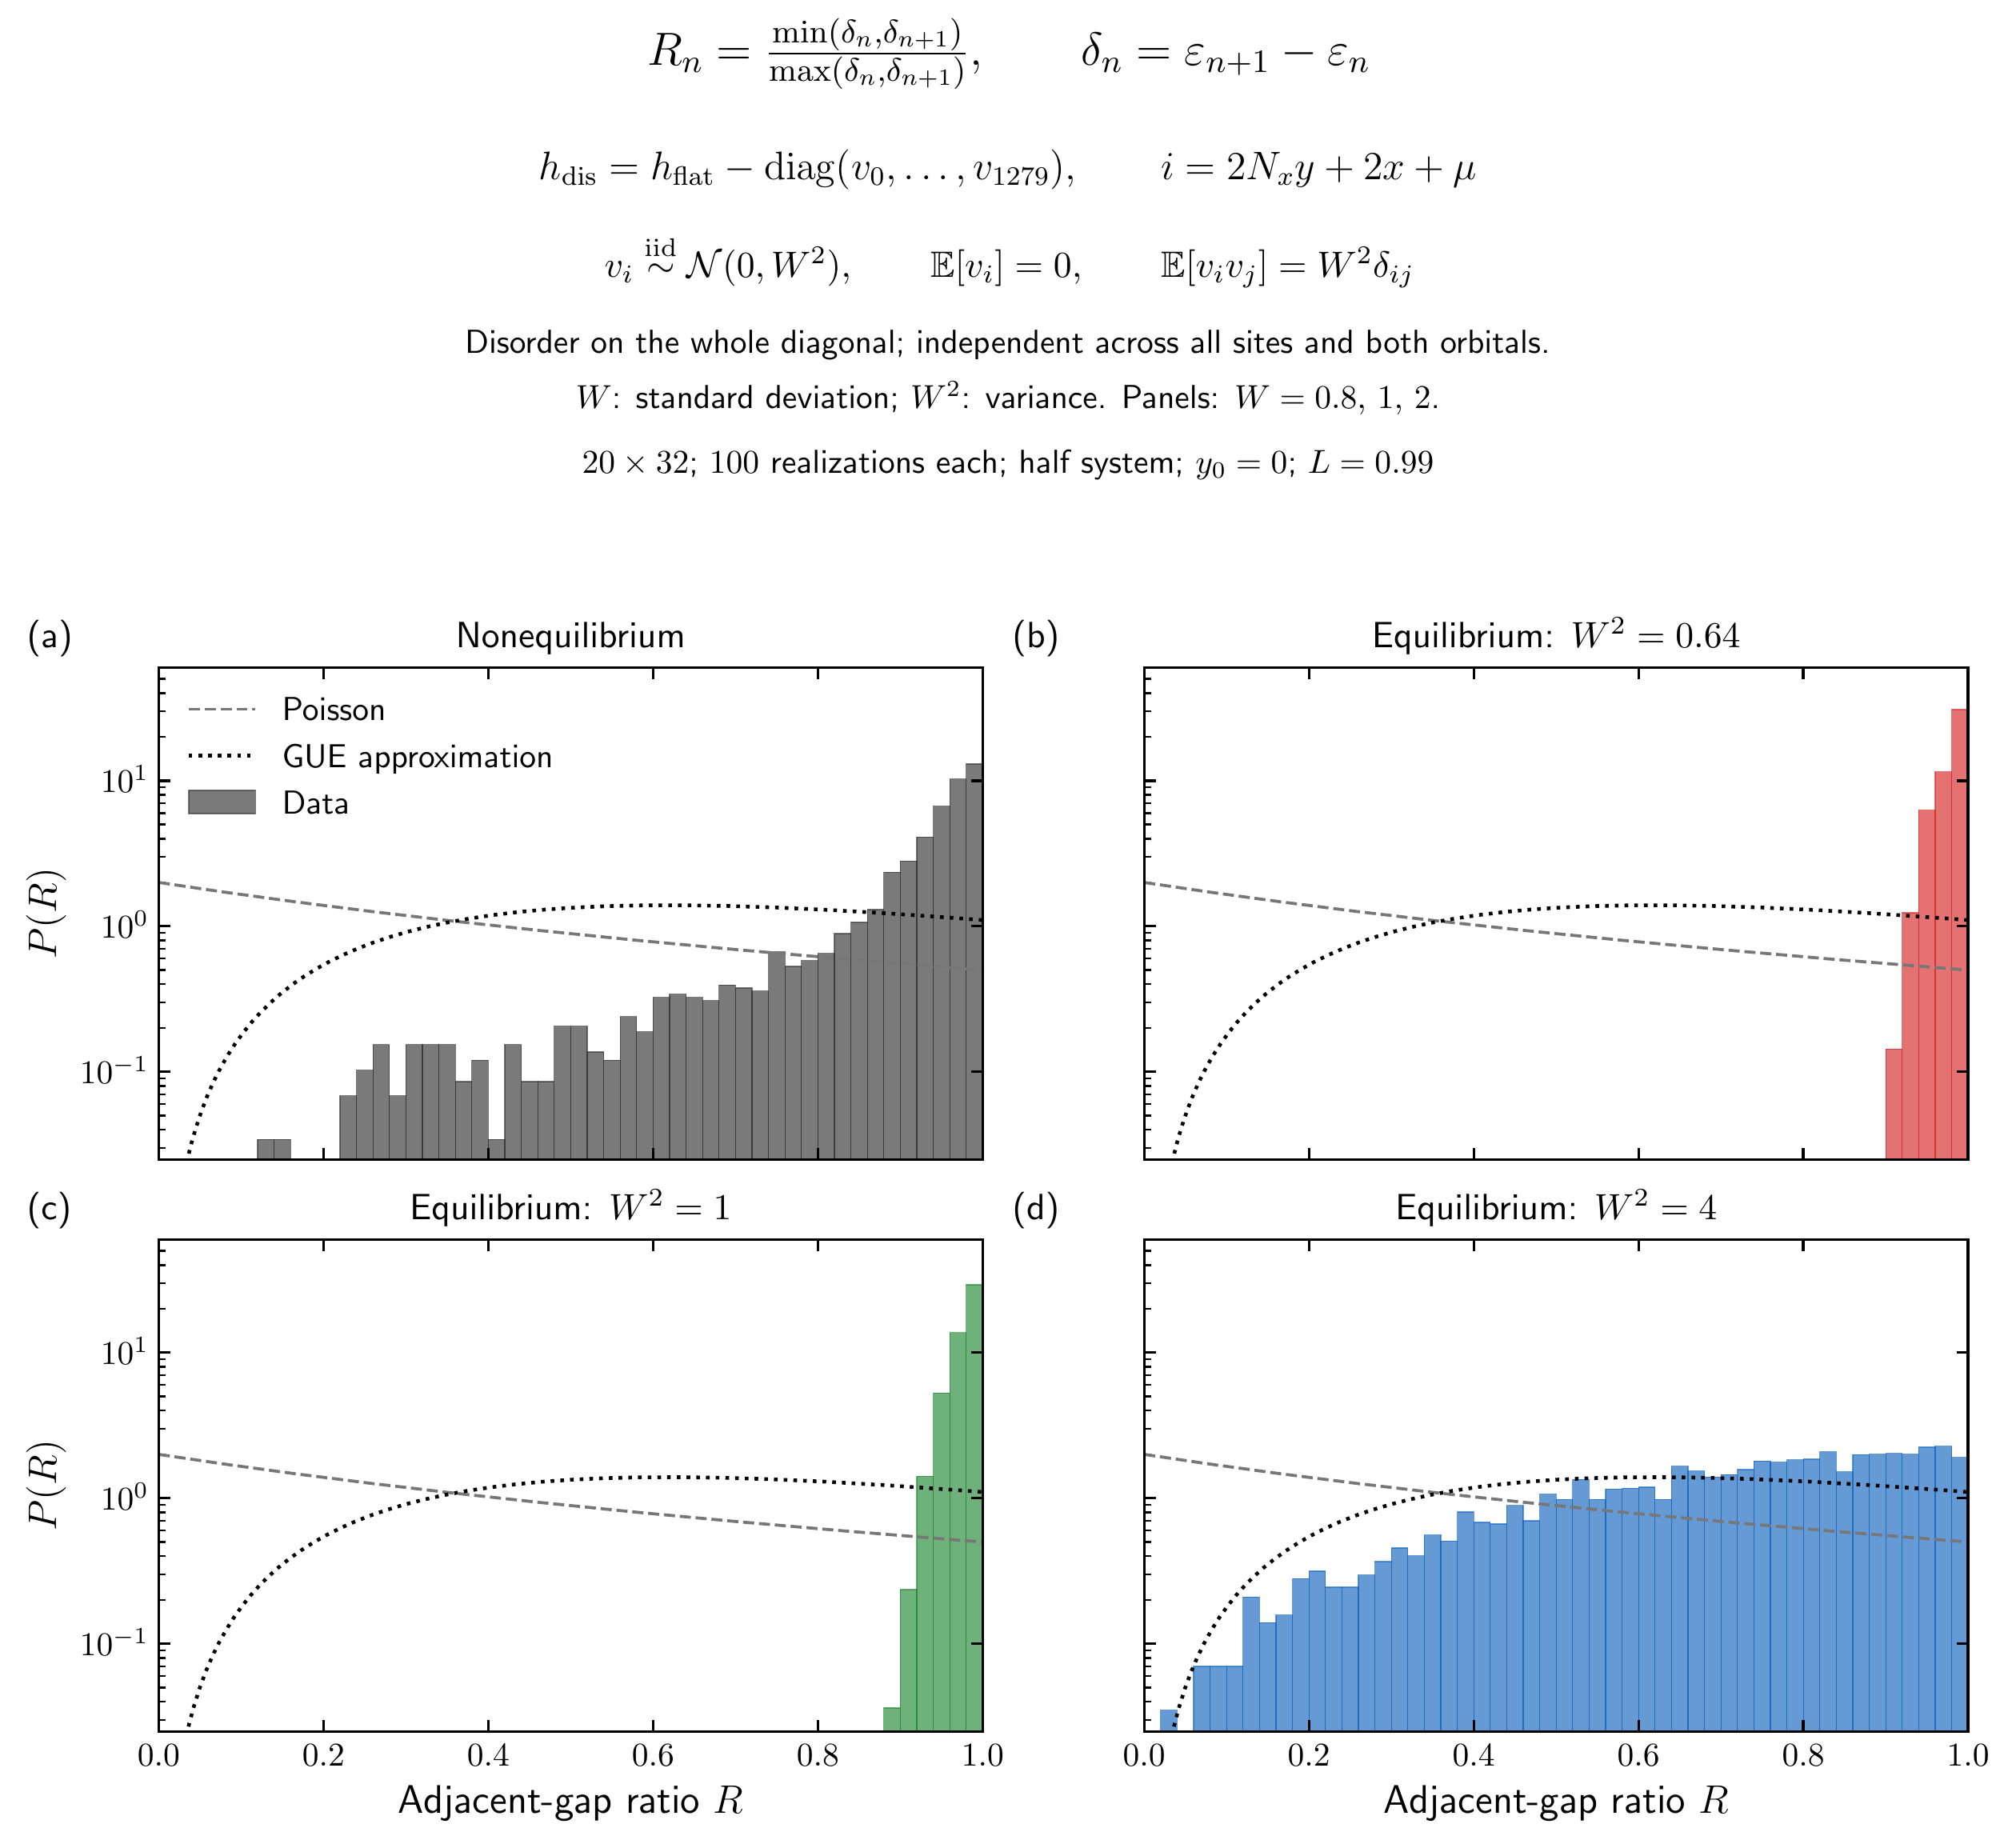

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],
 'font.size':8,'axes.labelsize':8,'axes.titlesize':8,'xtick.labelsize':8,'ytick.labelsize':8,
 'text.usetex':True,'text.latex.preamble':r'\usepackage{amsmath,amssymb}','pdf.fonttype':42,'xtick.direction':'in','ytick.direction':'in',
 'legend.fontsize':8,'legend.frameon':False})
R_BINS=50
redges=np.linspace(0,1,R_BINS+1)
x=np.linspace(.0001,1,1000)
poisson=2/(1+x)**2
Z=4*np.pi/(81*np.sqrt(3))
gue=2/Z*(x+x*x)**2/(1+x+x*x)**4
titles=['Nonequilibrium',r'Equilibrium: $W^2=0.64$',r'Equilibrium: $W^2=1$',r'Equilibrium: $W^2=4$']
colors=['#333333','#d62728','#228833','#1565c0']
fig,axes=plt.subplots(2,2,figsize=(8.4,7.7),sharex=True,sharey=True)
hist_rows=[]
for ax,label,title,color,letter in zip(axes.flat,labels,titles,colors,['(a)','(b)','(c)','(d)']):
    counts,_=np.histogram(results[label]['ratios'],redges)
    density=counts/(counts.sum()*np.diff(redges))
    assert counts.sum()==len(results[label]['ratios'])
    assert np.isclose(np.dot(density,np.diff(redges)),1)
    nz=counts>0
    ax.bar(redges[:-1][nz],density[nz],width=np.diff(redges)[nz],align='edge',
           color=color,alpha=.65,edgecolor=color,linewidth=.3,label='Data')
    ax.plot(x,poisson,'--',color='#777777',lw=.9,label='Poisson')
    ax.plot(x,gue,':',color='black',lw=1.1,label='GUE approximation')
    ax.set(title=title,xlim=(0,1),ylim=(.025,60),yscale='log')
    ax.tick_params(top=True,right=True,labelsize=10)
    ax.set_title(title,fontsize=11)
    ax.text(-.16,1.04,letter,transform=ax.transAxes,fontweight='bold',fontsize=11)
    for j,n in enumerate(counts):hist_rows.append({'ensemble':label,'left':redges[j],'right':redges[j+1],'count':int(n),'density':float(density[j])})
axes[0,0].legend(loc='upper left',fontsize=10)
for ax in axes[-1]:ax.set_xlabel(r'Adjacent-gap ratio $R$',fontsize=12)
for ax in axes[:,0]:ax.set_ylabel(r'$P(R)$',fontsize=12)
fig.suptitle(r'$R_n=\frac{\min(\delta_n,\delta_{n+1})}{\max(\delta_n,\delta_{n+1})},'
              r'\qquad \delta_n=\varepsilon_{n+1}-\varepsilon_n$',fontsize=14,y=.99)
fig.text(.5,.903,
         r'$h_{\mathrm{dis}}=h_{\mathrm{flat}}-\mathrm{diag}(v_0,\ldots,v_{1279}),'
         r'\qquad i=2N_xy+2x+\mu$',
         ha='center',fontsize=12)
fig.text(.5,.850,
         r'$v_i\overset{\mathrm{iid}}{\sim}\mathcal{N}(0,W^2),'
         r'\qquad \mathbb{E}[v_i]=0,\qquad'
         r'\mathbb{E}[v_iv_j]=W^2\delta_{ij}$',
         ha='center',fontsize=11)
fig.text(.5,.809,
         r'Disorder on the whole diagonal; independent across all sites and both orbitals.',
         ha='center',fontsize=10)
fig.text(.5,.779,
         r'$W$: standard deviation; $W^2$: variance. Panels: $W=0.8,\,1,\,2$.',
         ha='center',fontsize=10)
fig.text(.5,.744,r'$20\times32$; $100$ realizations each; half system; $y_0=0$; $L=0.99$',
         ha='center',fontsize=10)
fig.tight_layout(pad=1.0,rect=(0,0,1,.735))
pd.DataFrame(hist_rows).to_csv(OUT/'ratio_histograms.csv',index=False)
fig.savefig(OUT/'gap_ratio_distributions.pdf');plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'gap_ratio_distributions.pdf'),str(OUT/'gap_ratio_distributions')],check=True)
display(Image(filename=str(OUT/'gap_ratio_distributions.png'),width=1000))

## Mean gap ratios
Each point is the pooled mean of ratios computed within realizations. Error bars delete whole independent realizations. GUE and Poisson are comparison values; equality of neighboring gaps gives r=1.

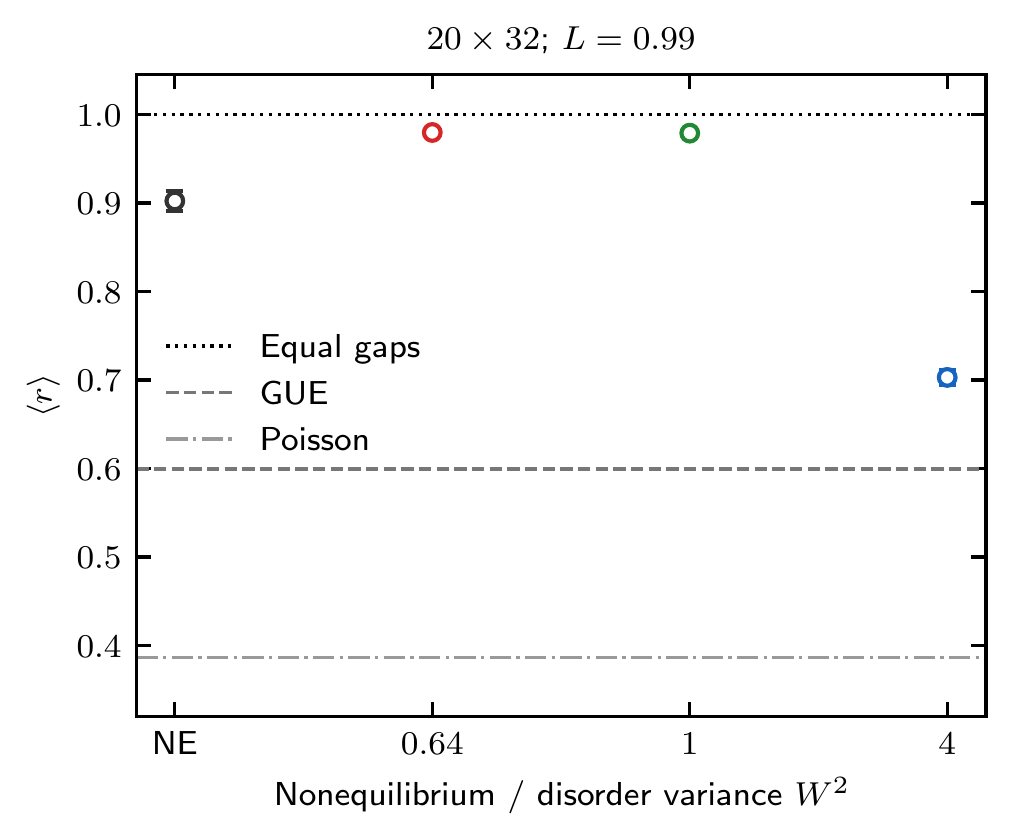

In [5]:
fig,ax=plt.subplots(figsize=(3.375,2.8))
for i,row in summary.iterrows():
    ax.errorbar(i,row.mean_r,yerr=row.mean_r_jackknife_se,fmt='o',mfc='white',
                color=colors[i],ms=4,lw=.9,capsize=2)
ax.axhline(1,color='black',lw=.8,ls=':',label='Equal gaps')
ax.axhline(.5996,color='#777777',lw=.8,ls='--',label='GUE')
ax.axhline(2*np.log(2)-1,color='#999999',lw=.8,ls='-.',label='Poisson')
ax.set(xticks=range(4),xticklabels=['NE',r'$0.64$',r'$1$',r'$4$'],
       xlabel=r'Nonequilibrium / disorder variance $W^2$',ylabel=r'$\langle r\rangle$',
       ylim=(.32,1.045),title=r'$20\times32$; $L=0.99$')
ax.tick_params(top=True,right=True)
ax.legend(loc='center left')
fig.tight_layout(pad=.8)
fig.savefig(OUT/'mean_gap_ratios.pdf');plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'mean_gap_ratios.pdf'),str(OUT/'mean_gap_ratios')],check=True)
display(Image(filename=str(OUT/'mean_gap_ratios.png'),width=600))

## Spacing distributions
These gaps are divided by the mean gap of their own realization. This is not full local unfolding; no random-matrix spacing curves are fitted to this plot.

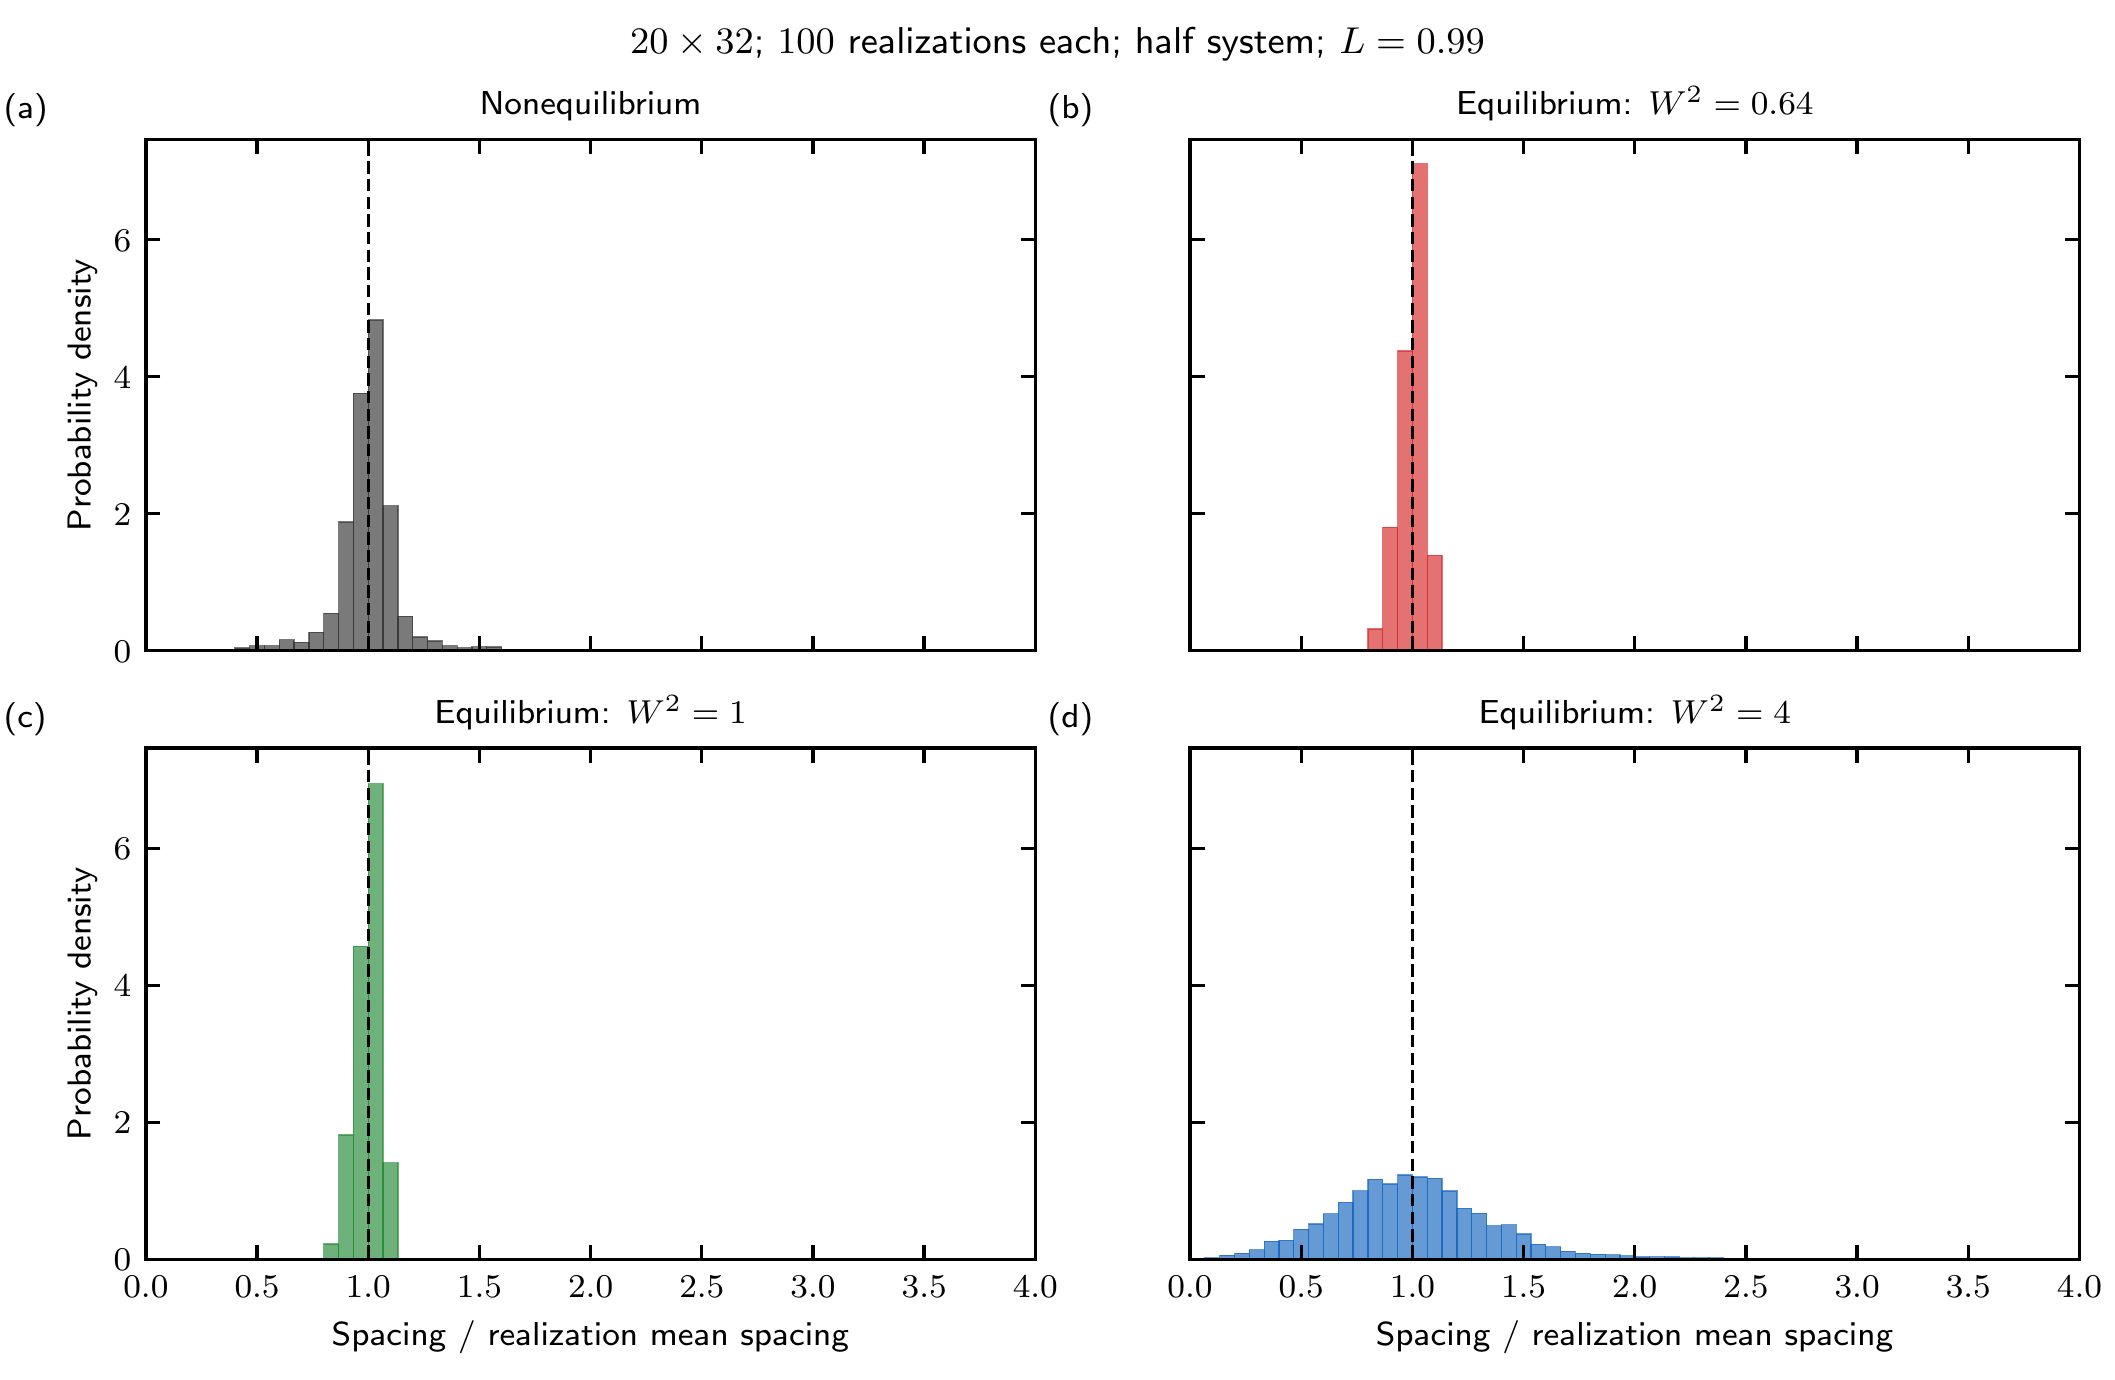

In [6]:
spacing_max=max(2.,float(np.ceil(max(np.max(v['spacings']) for v in results.values()))))
spacing_edges=np.linspace(0,spacing_max,61)
fig,axes=plt.subplots(2,2,figsize=(7.05,4.6),sharex=True,sharey=True)
spacing_rows=[]
for ax,label,title,color,letter in zip(axes.flat,labels,titles,colors,['(a)','(b)','(c)','(d)']):
    a=results[label]['spacings'];n,_=np.histogram(a,spacing_edges)
    rho=n/(len(a)*np.diff(spacing_edges));assert n.sum()==len(a)
    ax.bar(spacing_edges[:-1],rho,width=np.diff(spacing_edges),align='edge',
           color=color,alpha=.65,edgecolor=color,linewidth=.3)
    ax.axvline(1,color='black',ls='--',lw=.8)
    ax.set(title=title,xlim=(0,spacing_max))
    ax.tick_params(top=True,right=True)
    ax.text(-.16,1.04,letter,transform=ax.transAxes,fontweight='bold')
    for j,count in enumerate(n):spacing_rows.append({'ensemble':label,'left':spacing_edges[j],'right':spacing_edges[j+1],'count':int(count),'density':float(rho[j])})
for ax in axes[-1]:ax.set_xlabel(r'Spacing / realization mean spacing')
for ax in axes[:,0]:ax.set_ylabel('Probability density')
fig.suptitle(r'$20\times32$; $100$ realizations each; half system; $L=0.99$',fontsize=9)
fig.tight_layout(pad=.8)
pd.DataFrame(spacing_rows).to_csv(OUT/'spacing_histograms.csv',index=False)
fig.savefig(OUT/'spacing_distributions.pdf');plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'spacing_distributions.pdf'),str(OUT/'spacing_distributions')],check=True)
display(Image(filename=str(OUT/'spacing_distributions.png'),width=1000))

## Diagnostics and window sensitivity
The clean near-degenerate-pair control is not interpreted as Poisson statistics. Nonequilibrium and disorder comparisons use the same cut and energy variable.

In [7]:
diagnostics={'configuration':metadata,'ensembles':summary_rows,'clean_control':clean_summary,
 'sensitivity':sensitivity,'references':{'Poisson_mean':float(2*np.log(2)-1),'GUE_large_matrix_mean':.5996,
 'GUE_3x3_surmise_mean':float(2*np.sqrt(3)/np.pi-.5)},
 'checks':{'within_realization_spacings_only':True,'no_pair_merging':True,'finite_retained_energies':True,
 'ratio_histograms_unit_area':True,'input_checksums':True},
 'scope':'descriptive single-particle entanglement-level statistics; no sector-resolved or many-body-chaos claim'}
(OUT/'diagnostics.json').write_text(json.dumps(diagnostics,indent=2)+'\n')
display(pd.DataFrame(sensitivity)[['ensemble','L','mean_r','mean_r_jackknife_se','same_sign_mean_r']])
print('Clean-control mean r:',clean_summary['mean_r'])
print('Complete: 400 independent spectra; spacing and gap-ratio figures exported.')

,ensemble,L,mean_r,mean_r_jackknife_se,same_sign_mean_r
0,Nonequilibrium,0.50,0.901633,0.013874,0.899892
1,Nonequilibrium,0.90,0.902427,0.012273,0.902167
2,Nonequilibrium,0.95,0.903937,0.011769,0.903911
3,Nonequilibrium,0.99,0.902384,0.011521,0.902254
4,W2=0.64,0.50,0.990837,0.000622,0.990905
5,W2=0.64,0.90,0.987898,0.000505,0.987430
6,W2=0.64,0.95,0.988042,0.000406,0.987704
7,W2=0.64,0.99,0.979757,0.000395,0.978905
8,W2=1,0.50,0.985179,0.001012,0.984657
9,W2=1,0.90,0.984402,0.000748,0.984182


Clean-control mean r: 2.4177641922986454e-07
Complete: 400 independent spectra; spacing and gap-ratio figures exported.
